In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print('Kütüphaneler yüklendi ✓')

Kütüphaneler yüklendi ✓


## 1. Descriptive vs Inferential Statistics

In [3]:
# Popülasyon: 10.000 kullanıcının dinleme süresi (dakika)
np.random.seed(42)
populasyon = np.random.normal(loc=47, scale=12, size=10000)

# Örneklem: rastgele 200 kullanıcı
orneklem = np.random.choice(populasyon, size=200, replace=False)

print('=== DESCRIPTIVE (Betimsel) ===')
print(f'Örneklem ortalama : {orneklem.mean():.2f} dakika')
print(f'Örneklem medyan   : {np.median(orneklem):.2f} dakika')
print(f'Örneklem std      : {orneklem.std():.2f} dakika')

print('\n=== INFERENTIAL (Çıkarımsal) ===')
# Örneklemden popülasyonu tahmin et (güven aralığı)
guven_araligi = stats.t.interval(
    confidence=0.95,
    df=len(orneklem)-1,
    loc=orneklem.mean(),
    scale=stats.sem(orneklem)
)
print(f'%95 güven aralığı : {guven_araligi[0]:.2f} — {guven_araligi[1]:.2f} dakika')
print(f'Gerçek popülasyon : {populasyon.mean():.2f} dakika')

=== DESCRIPTIVE (Betimsel) ===
Örneklem ortalama : 48.27 dakika
Örneklem medyan   : 48.08 dakika
Örneklem std      : 12.62 dakika

=== INFERENTIAL (Çıkarımsal) ===
%95 güven aralığı : 46.51 — 50.04 dakika
Gerçek popülasyon : 46.97 dakika


## 2. Mean, Median, Mode — ve Outlier Etkisi

=== OUTLIER OLMADAN ===
Ortalama : 30,000 TL
Medyan   : 30,000 TL
Mod      : 25,000 TL

=== OUTLIER İLE (CEO maaşı: 250.000 TL) ===
Ortalama : 66,667 TL  ← çarpıtıldı!
Medyan   : 31,000 TL  ← sağlam kaldı


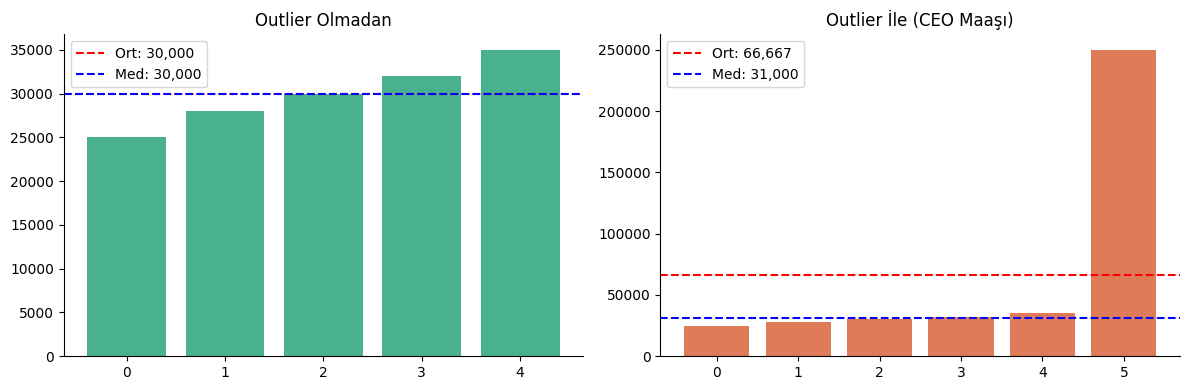

In [4]:
# Normal veri
maaslar = [25000, 28000, 30000, 32000, 35000]

# Outlier eklenmiş veri (CEO maaşı)
maaslar_outlier = [25000, 28000, 30000, 32000, 35000, 250000]

print('=== OUTLIER OLMADAN ===')
print(f'Ortalama : {np.mean(maaslar):,.0f} TL')
print(f'Medyan   : {np.median(maaslar):,.0f} TL')
print(f'Mod      : {stats.mode(maaslar, keepdims=True).mode[0]:,.0f} TL')

print('\n=== OUTLIER İLE (CEO maaşı: 250.000 TL) ===')
print(f'Ortalama : {np.mean(maaslar_outlier):,.0f} TL  ← çarpıtıldı!')
print(f'Medyan   : {np.median(maaslar_outlier):,.0f} TL  ← sağlam kaldı')

# Görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(len(maaslar)), maaslar, color='#1D9E75', alpha=0.8)
axes[0].axhline(np.mean(maaslar), color='red', linestyle='--', label=f'Ort: {np.mean(maaslar):,.0f}')
axes[0].axhline(np.median(maaslar), color='blue', linestyle='--', label=f'Med: {np.median(maaslar):,.0f}')
axes[0].set_title('Outlier Olmadan')
axes[0].legend()

axes[1].bar(range(len(maaslar_outlier)), maaslar_outlier, color='#D85A30', alpha=0.8)
axes[1].axhline(np.mean(maaslar_outlier), color='red', linestyle='--', label=f'Ort: {np.mean(maaslar_outlier):,.0f}')
axes[1].axhline(np.median(maaslar_outlier), color='blue', linestyle='--', label=f'Med: {np.median(maaslar_outlier):,.0f}')
axes[1].set_title('Outlier İle (CEO Maaşı)')
axes[1].legend()

plt.tight_layout()
plt.savefig('plots/mean_median_outlier.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Variance & Standard Deviation

--- Takım A ---
  Ortalama          : 108.0
  Varyans (pop)     : 3.60
  Varyans (sample)  : 4.50  ← n-1 (Bessel)
  Standart Sapma    : 2.12

--- Takım B ---
  Ortalama          : 108.0
  Varyans (pop)     : 269.60
  Varyans (sample)  : 337.00  ← n-1 (Bessel)
  Standart Sapma    : 18.36



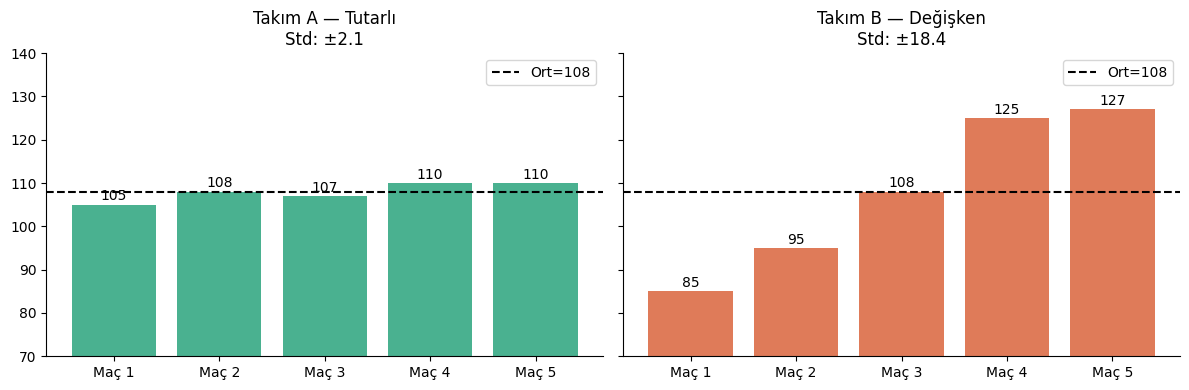

In [5]:
# NBA örneği
takim_a = np.array([105, 108, 107, 110, 110])  # tutarlı
takim_b = np.array([85,  95,  108, 125, 127])  # değişken

for isim, skor in [('Takım A', takim_a), ('Takım B', takim_b)]:
    print(f'--- {isim} ---')
    print(f'  Ortalama          : {skor.mean():.1f}')
    print(f'  Varyans (pop)     : {skor.var():.2f}')
    print(f'  Varyans (sample)  : {skor.var(ddof=1):.2f}  ← n-1 (Bessel)')  
    print(f'  Standart Sapma    : {skor.std(ddof=1):.2f}')
    print()

# Görselleştirme
x = np.arange(1, 6)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, skor, renk, baslik in [
    (axes[0], takim_a, '#1D9E75', 'Takım A — Tutarlı'),
    (axes[1], takim_b, '#D85A30', 'Takım B — Değişken')
]:
    ax.bar(x, skor, color=renk, alpha=0.8)
    ax.axhline(skor.mean(), color='black', linestyle='--', linewidth=1.5, label=f'Ort={skor.mean():.0f}')
    ax.set_xticks(x)
    ax.set_xticklabels([f'Maç {i}' for i in x])
    ax.set_ylim(70, 140)
    ax.set_title(f'{baslik}\nStd: ±{skor.std(ddof=1):.1f}')
    ax.legend()
    for i, v in enumerate(skor):
        ax.text(i+1, v+1, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('plots/variance_std.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Percentile & Quartile

=== 5-Number Summary ===
Min     : 18 bin TL
Q1 (P25): 25.75 bin TL
Medyan  : 32.5 bin TL
Q3 (P75): 41.0 bin TL
Max     : 80 bin TL
IQR     : 15.25 bin TL

Outlier sınırı: 2.9 — 63.9
Outlierlar    : [80]


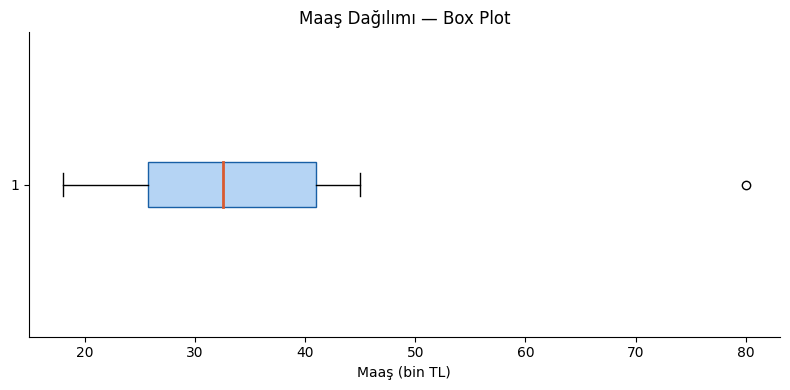

In [6]:
# Çalışan maaşları
maaslar = np.array([18, 22, 25, 28, 30, 35, 38, 42, 45, 80])  # bin TL

q1  = np.percentile(maaslar, 25)
med = np.percentile(maaslar, 50)
q3  = np.percentile(maaslar, 75)
iqr = q3 - q1

print('=== 5-Number Summary ===')
print(f'Min     : {maaslar.min()} bin TL')
print(f'Q1 (P25): {q1} bin TL')
print(f'Medyan  : {med} bin TL')
print(f'Q3 (P75): {q3} bin TL')
print(f'Max     : {maaslar.max()} bin TL')
print(f'IQR     : {iqr} bin TL')

# Outlier tespiti (1.5 * IQR kuralı)
alt_sinir = q1 - 1.5 * iqr
ust_sinir = q3 + 1.5 * iqr
outliers = maaslar[(maaslar < alt_sinir) | (maaslar > ust_sinir)]
print(f'\nOutlier sınırı: {alt_sinir:.1f} — {ust_sinir:.1f}')
print(f'Outlierlar    : {outliers}')

# Box plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(maaslar, vert=False, patch_artist=True,
           boxprops=dict(facecolor='#B5D4F4', color='#185FA5'),
           medianprops=dict(color='#D85A30', linewidth=2))
ax.set_xlabel('Maaş (bin TL)')
ax.set_title('Maaş Dağılımı — Box Plot')
plt.tight_layout()
plt.savefig('plots/boxplot_percentile.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Covariance & Correlation

Kovaryans  : 25.00  (birime bağımlı)
Korelasyon : 1.0000  (-1 ile +1 arası)


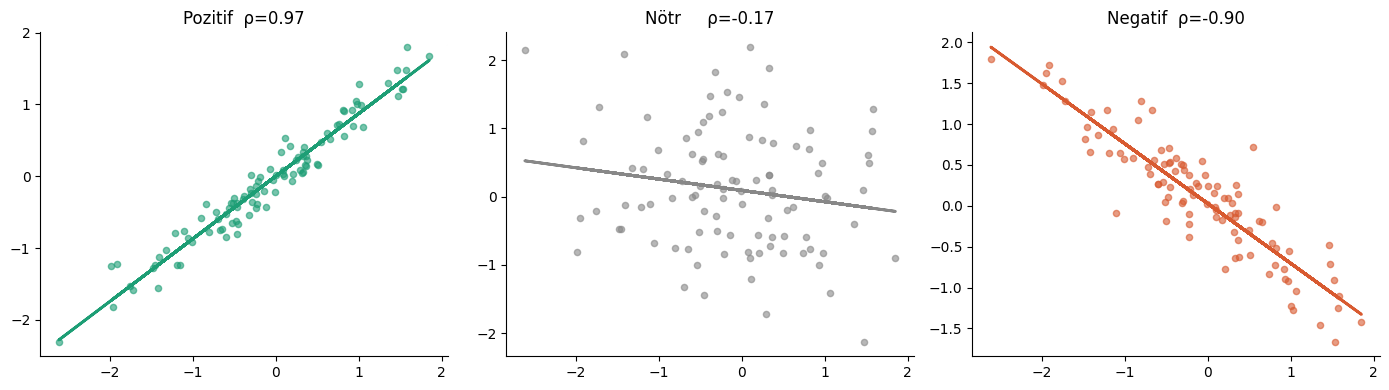


Pearson  r=1.0000, p=0.0000
Spearman r=1.0000, p=0.0000


In [7]:
# Hava sıcaklığı & dondurma satışı
sicaklik  = np.array([20, 22, 24, 26, 28])
satis     = np.array([40, 45, 50, 55, 60])

kovaryans   = np.cov(sicaklik, satis)[0][1]
korelasyon  = np.corrcoef(sicaklik, satis)[0][1]

print(f'Kovaryans  : {kovaryans:.2f}  (birime bağımlı)')
print(f'Korelasyon : {korelasyon:.4f}  (-1 ile +1 arası)')

# Farklı korelasyon senaryoları
np.random.seed(42)
n = 100
x = np.random.randn(n)

y_pos  = 0.9 * x + 0.2 * np.random.randn(n)   # pozitif
y_neg  = -0.8 * x + 0.3 * np.random.randn(n)  # negatif
y_none = np.random.randn(n)                     # ilişki yok

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, y, renk, baslik in [
    (axes[0], y_pos,  '#1D9E75', f'Pozitif  ρ={np.corrcoef(x,y_pos)[0,1]:.2f}'),
    (axes[1], y_none, '#888888', f'Nötr     ρ={np.corrcoef(x,y_none)[0,1]:.2f}'),
    (axes[2], y_neg,  '#D85A30', f'Negatif  ρ={np.corrcoef(x,y_neg)[0,1]:.2f}')
]:
    ax.scatter(x, y, color=renk, alpha=0.6, s=20)
    m, b = np.polyfit(x, y, 1)
    ax.plot(x, m*x+b, color=renk, linewidth=2)
    ax.set_title(baslik)

plt.tight_layout()
plt.savefig('plots/correlation_types.png', dpi=150, bbox_inches='tight')
plt.show()

# Pearson vs Spearman
from scipy.stats import pearsonr, spearmanr
p_r, p_p = pearsonr(sicaklik, satis)
s_r, s_p = spearmanr(sicaklik, satis)
print(f'\nPearson  r={p_r:.4f}, p={p_p:.4f}')
print(f'Spearman r={s_r:.4f}, p={s_p:.4f}')

## 6. Probability (Olasılık)

=== Temel Olasılık Örnekleri ===
Para — Tura   : 0.50 = %50
Zar  — 4 gelmesi : 0.1667 = %16.7
Zar  — çift sayı : 0.50 = %50

=== E-ticaret Dönüşüm Olasılığı ===
Satın alma olasılığı: 0.035 = %3.5
  1 gelme frekansı: 0.172 (teorik: 0.167)
  2 gelme frekansı: 0.170 (teorik: 0.167)
  3 gelme frekansı: 0.174 (teorik: 0.167)
  4 gelme frekansı: 0.137 (teorik: 0.167)
  5 gelme frekansı: 0.176 (teorik: 0.167)
  6 gelme frekansı: 0.171 (teorik: 0.167)


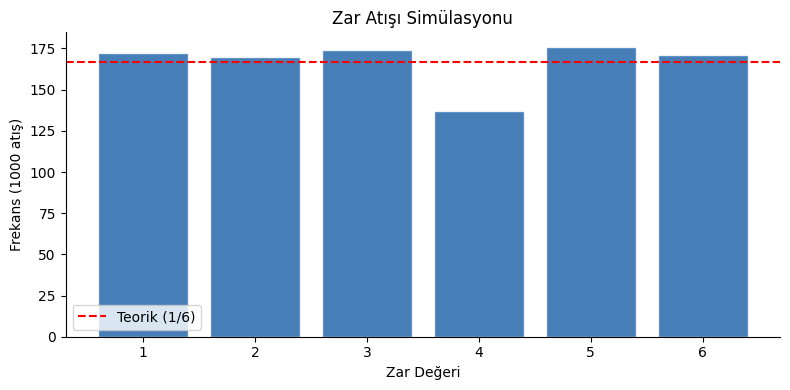

In [8]:
# Temel olasılık
def olasilik(istenen, toplam):
    return istenen / toplam

print('=== Temel Olasılık Örnekleri ===')
print(f'Para — Tura   : {olasilik(1, 2):.2f} = %{olasilik(1,2)*100:.0f}')
print(f'Zar  — 4 gelmesi : {olasilik(1, 6):.4f} = %{olasilik(1,6)*100:.1f}')
print(f'Zar  — çift sayı : {olasilik(3, 6):.2f} = %{olasilik(3,6)*100:.0f}')

# E-ticaret örneği
print('\n=== E-ticaret Dönüşüm Olasılığı ===')
ziyaretci = 1000
satin_alan = 35
p_satin = olasilik(satin_alan, ziyaretci)
print(f'Satın alma olasılığı: {p_satin:.3f} = %{p_satin*100:.1f}')

# Simülasyon: 1000 zar atışı
atislar = np.random.randint(1, 7, size=1000)
for sayi in range(1, 7):
    frekans = np.sum(atislar == sayi) / 1000
    print(f'  {sayi} gelme frekansı: {frekans:.3f} (teorik: 0.167)')

# Histogram
fig, ax = plt.subplots(figsize=(8, 4))
renkler = ['#185FA5'] * 6
sayimlar = [np.sum(atislar == i) for i in range(1, 7)]
ax.bar(range(1, 7), sayimlar, color=renkler, alpha=0.8, edgecolor='white')
ax.axhline(1000/6, color='red', linestyle='--', label='Teorik (1/6)')
ax.set_xticks(range(1, 7))
ax.set_xlabel('Zar Değeri')
ax.set_ylabel('Frekans (1000 atış)')
ax.set_title('Zar Atışı Simülasyonu')
ax.legend()
plt.tight_layout()
plt.savefig('plots/probability_simulation.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Özet — Pandas ile Hızlı İstatistik

=== describe() ile 5-Number Summary ===
          yas      maas  deneyim  memnuniyet
count  200.00    200.00   200.00      200.00
mean    39.58  35520.98     9.18        2.93
std     12.03   9849.87     5.85        1.42
min     20.00   2587.00     0.00        1.00
25%     28.00  28033.25     4.00        2.00
50%     41.00  36065.50     9.00        3.00
75%     51.00  41664.50    14.00        4.00
max     59.00  73527.00    19.00        5.00

=== Korelasyon Matrisi ===
              yas   maas  deneyim  memnuniyet
yas         1.000 -0.090   -0.069       0.080
maas       -0.090  1.000    0.063      -0.021
deneyim    -0.069  0.063    1.000      -0.060
memnuniyet  0.080 -0.021   -0.060       1.000


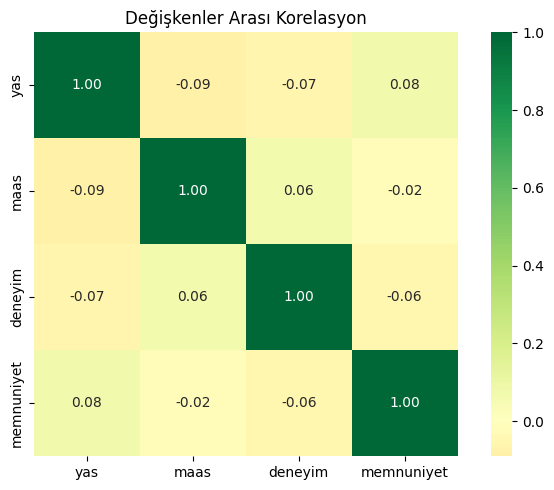

In [9]:
# Gerçekçi bir dataset
np.random.seed(42)
df = pd.DataFrame({
    'yas'       : np.random.randint(20, 60, 200),
    'maas'      : np.random.normal(35000, 10000, 200).astype(int),
    'deneyim'   : np.random.randint(0, 20, 200),
    'memnuniyet': np.random.randint(1, 6, 200)
})

print('=== describe() ile 5-Number Summary ===')
print(df.describe().round(2))

print('\n=== Korelasyon Matrisi ===')
print(df.corr(numeric_only=True).round(3))

# Korelasyon ısı haritası
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, ax=ax, square=True)
ax.set_title('Değişkenler Arası Korelasyon')
plt.tight_layout()
plt.savefig('plots/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()